In [ ]:
import kagglehub
# kagglehub.login()
!pip install lpips

In [ ]:
path = kagglehub.dataset_download("subinium/highresolution-anime-face-dataset-512x512")

Using Colab cache for faster access to the 'highresolution-anime-face-dataset-512x512' dataset.


In [252]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy
import os
import albumentations as A
import matplotlib.pyplot as plt
import math
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
from torchvision.utils import make_grid
import cv2
import copy
import lpips

In [ ]:
os.listdir(path)

['portraits']

In [ ]:
ROOT = path+'/portraits/'
DEVICE = 'cuda'

VAE_BATCH_SIZE = 16
UNET_BATCH_SIZE = 16

VAE_BASE_DIM = 64
UNET_BASE_DIM = 96

VAE_EPOCHS = 30
UNET_EPOCHS = 300

GROUPS = 8

VAE_LR = 2e-4
UNET_LR = 1e-4

TIME_DIM = 384
T = 228
IMG_SIZE = 256
BETA = 4e-4
LATENT_DIM = 4
NUM_WORKERS = 32
EDGE_WEIGHT = 0.10
LPIP_WEIGHT = 0.25

VAE_PATH = "/content/drive/MyDrive/Colab Notebooks/models/vae_WW.pth"
UNET_PATH = "/content/drive/MyDrive/Colab Notebooks/models/ema_unet_L.pth"
CACHE_PATH = "/content/drive/MyDrive/Colab Notebooks/models/cache.pth"

In [ ]:
data =  pd.DataFrame({"paths":os.listdir(ROOT)}).iloc[:10000]
data

,paths
0,23830210.jpg
1,15212720.jpg
2,5636711.jpg
3,30921350.jpg
4,10044670.jpg
...,...
9995,26049920.jpg
9996,18684240.jpg
9997,33307460.jpg
9998,13646130.jpg


# VAE

In [ ]:
# @title
class vae_dataset(Dataset):
  def __init__(self, df, transform,  img_size, root) -> None:
    self.df = df
    self.transform = transform
    self.img_size = img_size
    self.root = root

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    path = self.root+self.df.iloc[idx]['paths']
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if self.transform:
      img = self.transform(image=img)
    return img['image']

transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    A.ToTensorV2(),
])
vae_dt = vae_dataset(df=data, transform=transform, img_size=IMG_SIZE, root=ROOT)
vae_loader = DataLoader(vae_dt, batch_size=VAE_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

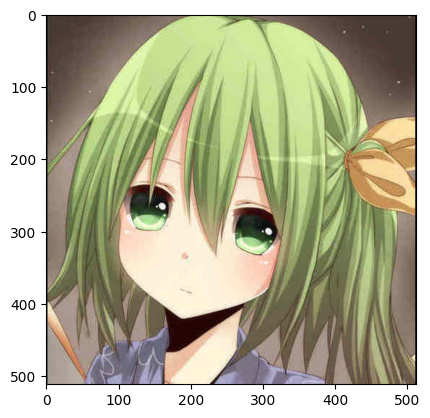

In [ ]:
# @title
plt.imshow(cv2.cvtColor(cv2.imread(ROOT + data.iloc[67]['paths']), cv2.COLOR_BGR2RGB))

In [ ]:
# @title
class ResBlock(nn.Module):
  def __init__(self, ch):
    super().__init__()
    self.layer = nn.Sequential(
        nn.GroupNorm(8, ch),
        nn.SiLU(),
        nn.Conv2d(ch, ch, kernel_size=3, padding=1),
        nn.GroupNorm(8, ch),
        nn.SiLU(),
        nn.Conv2d(ch, ch, kernel_size=3, padding=1),
    )
  def forward(self, x):
    h = self.layer(x)
    return x + h

In [ ]:
# @title
class Upsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)

In [ ]:
# @title
class Downsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
# @title
class VAE(nn.Module):
  def __init__(self, ch, latent):
    super().__init__()
    self.enc = nn.Sequential(
        nn.Conv2d(3, ch, kernel_size=3, padding=1),

        ResBlock(ch),
        ResBlock(ch),
        Downsample(ch, ch *2),
        ResBlock(ch *2),
        ResBlock(ch *2),
        Downsample(ch *2, ch *4),
        ResBlock(ch *4),
        ResBlock(ch *4),
        Downsample(ch *4, ch *4),
        ResBlock(ch *4),
        ResBlock(ch *4),
    )

    self.mu = nn.Conv2d(ch *4, latent, kernel_size=3, padding=1)
    self.logv = nn.Conv2d(ch *4, latent, kernel_size=3, padding=1)

    self.dec = nn.Sequential(
        nn.Conv2d(latent, ch *4, kernel_size=3, padding=1),
        ResBlock(ch *4),
        ResBlock(ch *4),
        Upsample(ch *4, ch *4),
        ResBlock(ch *4),
        ResBlock(ch *4),
        Upsample(ch *4, ch *2),
        ResBlock(ch *2),
        ResBlock(ch *2),
        Upsample(ch *2, ch),
        ResBlock(ch),
        ResBlock(ch),

        nn.GroupNorm(8, ch),
        nn.SiLU(),
        nn.Conv2d(ch, 3, kernel_size=3, padding=1),
        nn.Tanh(),
    )

  def encode(self, x):
    h = self.enc(x)
    mu = self.mu(h)
    logv = self.logv(h)
    return mu, logv

  def decode(self, z):
      return self.dec(z)

  def reparameterize(self, mu, logv):
    std = torch.exp(logv*0.5)
    noise = torch.randn_like(std)
    return mu + std * noise

  def forward(self, x):
    mu, logv = self.encode(x)
    z = self.reparameterize(mu, logv)
    recon = self.decode(z)
    return recon, mu, logv, z

In [ ]:
# @title
def sobel_edges(x):
    B, C, H, W = x.shape

    kx = torch.tensor(
        [[-1, 0, 1],
         [-2, 0, 2],
         [-1, 0, 1]],
        dtype=x.dtype,
        device=x.device
    ).view(1, 1, 3, 3)

    ky = torch.tensor(
        [[-1, -2, -1],
         [0, 0, 0],
         [1, 2, 1]],
        dtype=x.dtype,
        device=x.device
    ).view(1, 1, 3, 3)

    kx = kx.repeat(C, 1, 1, 1)
    ky = ky.repeat(C, 1, 1, 1)

    gx = F.conv2d(x, kx, padding=1, groups=C)
    gy = F.conv2d(x, ky, padding=1, groups=C)

    return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

In [ ]:
# @title
def train_vae(vae, loader, beta, edge, lpip_w):
  vae.train()
  ttl_loss = 0
  ttl_recon_loss = 0
  ttl_kl_loss = 0
  ttl_edge_loss = 0
  ttl_perc_loss = 0
  for x in tqdm(loader):
    x = x.to(DEVICE)
    recon, mu, logv, z = vae(x)

    recon_loss = F.l1_loss(recon, x).mean()
    kl_loss = 0.5 * torch.mean(mu.pow(2) - logv + logv.exp() - 1)
    edge_loss = F.l1_loss(sobel_edges(recon),sobel_edges(x))
    perc_loss = lpips_fn(recon, x).mean()
    loss = recon_loss + kl_loss * beta + edge_loss * edge + perc_loss * lpip_w

    vae_optimizer.zero_grad()
    loss.backward()
    vae_optimizer.step()

    ttl_loss += loss.item()
    ttl_recon_loss += recon_loss.item()
    ttl_edge_loss += edge_loss.item() * edge
    ttl_kl_loss += kl_loss.item() * beta
    ttl_perc_loss += perc_loss.item() * lpip_w


  grid_real = make_grid((recon[:8] + 1) / 2, nrow=8)
  plt.figure(figsize=(20, 5))
  plt.imshow(grid_real.detach().cpu().permute(1,2,0))
  plt.show()

  ttl_loss /= len(loader)
  ttl_recon_loss /= len(loader)
  ttl_kl_loss /= len(loader)
  ttl_edge_loss /= len(loader)
  ttl_perc_loss /= len(loader)

  return ttl_loss, ttl_recon_loss, ttl_kl_loss, ttl_edge_loss, ttl_perc_loss

In [ ]:
# @title
vae = VAE(ch=VAE_BASE_DIM, latent=LATENT_DIM).to(DEVICE)
# for param in vae.parameters():
#   param.requires_grad = False
# for param in vae.dec.parameters():
#   param.requires_grad = True
vae_optimizer = optim.AdamW(vae.parameters(), lr=VAE_LR)
vae.load_state_dict(torch.load(VAE_PATH, map_location=DEVICE))

lpips_fn = lpips.LPIPS(net='vgg').to(DEVICE)
lpips_fn.eval()
for param in lpips_fn.parameters():
  param.requires_grad = False

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


In [ ]:
# @title
# # @title
# for epoch in range(VAE_EPOCHS):
#   loss, recon, kl, edge, perc = train_vae(vae, vae_loader, BETA, EDGE_WEIGHT, LPIP_WEIGHT)
#   print(f"Epoch: {epoch+1}/{VAE_EPOCHS}, Loss: {loss}, Recon_Loss: {recon}, KL_Loss: {kl}, Edge: {edge}, Perc: {perc}")

In [ ]:
# @title
# torch.save(vae.state_dict(), VAE_PATH)

In [ ]:
# @title
@torch.no_grad()
def check_latent_stats(vae, loader, max_batches=50):
    vae.eval()
    zs = []

    for i, x in enumerate(loader):
        if i >= max_batches:
            break

        x = x.to(DEVICE)
        mu, logv = vae.encode(x)
        zs.append(mu.detach().flatten())

    zs = torch.cat(zs)

    print("latent mean:", zs.mean().item())
    print("latent std:", zs.std().item())
    print("latent min:", zs.min().item())
    print("latent max:", zs.max().item())
    return zs.std().item(), zs.mean().item()

LATENT_STD, LATENT_MEAN = check_latent_stats(vae, vae_loader)

latent mean: 0.01858549378812313
latent std: 1.3238714933395386
latent min: -7.189389705657959
latent max: 8.084244728088379


In [ ]:
# @title
@torch.no_grad()
def cache_latents(vae, loader, path):
  vae.eval()
  all_z = []
  for x in tqdm(loader):
    x = x.to(DEVICE)
    mu, logv = vae.encode(x)
    z = (mu-LATENT_MEAN) / LATENT_STD
    all_z.append(z.cpu())

  all_z = torch.cat(all_z, dim=0)
  torch.save(all_z, path)
  print(f"Saved to {path}")
cache_latents(vae, vae_loader, CACHE_PATH)

100%|██████████| 625/625 [00:17<00:00, 36.70it/s]


Saved to /content/drive/MyDrive/Colab Notebooks/models/cache.pth


# UNET

In [ ]:
class unet_dataset(Dataset):
  def __init__(self, path):
    self.z = torch.load(path)

  def __len__(self):
    return self.z.shape[0]

  def __getitem__(self, idx):
    return self.z[idx]
unet_dt = unet_dataset(CACHE_PATH)
unet_loader = DataLoader(unet_dt, batch_size=UNET_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
betas = torch.linspace(1e-4, 0.035, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

In [ ]:
def q_sample(x0, t, noise):
  alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
  x_t = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1-alpha_bar_t) * noise
  return x_t

In [ ]:
# @title
class SinusoidalPosEmb(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.dim = dim

  def forward(self, t):
    device = t.device
    half_dim = self.dim//2
    emb_scale = math.log(10000) / (half_dim-1)
    emb = torch.exp(torch.arange(half_dim, device=device) * (-emb_scale))
    emb = t.unsqueeze(-1).float() * emb.unsqueeze(0)
    emb = torch.cat([emb.sin(), emb.cos()], dim=1)
    return emb

In [ ]:
# @title
class Attention(nn.Module):
  def __init__(self, ch, heads=8, groups=8):
    super().__init__()
    self.norm = nn.GroupNorm(groups, ch)
    self.att = nn.MultiheadAttention(ch, heads, batch_first=True)

  def forward(self, x):
    B, C, H, W = x.shape
    h = self.norm(x)
    h = h.flatten(2).permute(0, 2, 1)
    h,_ = self.att(h, h, h, need_weights=False)
    h = h.permute(0, 2, 1).reshape(B, C, H, W)

    return x + h

In [ ]:
# @title
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.00):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch * 2),
        )

        self.norm1 = nn.GroupNorm(GROUPS, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(GROUPS, out_ch)
        self.dropout = nn.Dropout2d(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.act = nn.SiLU()

        if in_ch != out_ch:
            self.res_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        else:
            self.res_conv = nn.Identity()

    def forward(self, x, t_emb):
        h = self.norm1(x)
        h = self.act(h)
        h = self.conv1(h)

        scale, shift = self.time_mlp(t_emb).chunk(2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.act(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return (h + self.res_conv(x)) / math.sqrt(2)

In [ ]:
# @title
class UNET(nn.Module):
    def __init__(
        self,
        latent=4,
        base_dim=64,
        time_dim=128,
        num_blocks=3,
        level_mul=(1, 2, 4),
        level_att=(False, True, True),
        self_condition=True,
    ):
        super().__init__()

        self.self_condition = self_condition

        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )

        dims = [base_dim * i for i in level_mul]

        in_latent_ch = latent * 2 if self_condition else latent
        self.inp = nn.Conv2d(in_latent_ch, dims[0], kernel_size=3, padding=1)

        self.downblocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        for i, out_ch in enumerate(dims):
            blocks = nn.ModuleList(
                [Block(out_ch, out_ch, time_dim) for _ in range(num_blocks)]
            )

            att = Attention(out_ch) if level_att[i] else nn.Identity()

            self.downblocks.append(
                nn.ModuleDict({
                    "blocks": blocks,
                    "attn": att,
                })
            )

            if i != len(dims) - 1:
                self.downsamples.append(Downsample(out_ch, dims[i + 1]))

        self.mid_block1 = Block(dims[-1], dims[-1], time_dim)
        self.mid_attn = Attention(dims[-1])
        self.mid_block2 = Block(dims[-1], dims[-1], time_dim)

        self.upblocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        rev_dims = list(reversed(dims))
        rev_attn = list(reversed(level_att))

        for i in range(len(rev_dims) - 1):
            in_ch = rev_dims[i]
            skip_ch = rev_dims[i + 1]
            out_ch = rev_dims[i + 1]

            self.upsamples.append(Upsample(in_ch, out_ch))

            blocks = nn.ModuleList(
                [Block(out_ch + skip_ch, out_ch, time_dim)] +
                [Block(out_ch, out_ch, time_dim) for _ in range(num_blocks - 1)]
            )

            use_attn = rev_attn[i + 1]
            att = Attention(out_ch) if use_attn else nn.Identity()

            self.upblocks.append(
                nn.ModuleDict({
                    "blocks": blocks,
                    "attn": att,
                })
            )

        self.out = nn.Conv2d(base_dim, latent, kernel_size=3, padding=1)

        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def apply_blocks(self, blocks, x, t_emb):
        for block in blocks:
            x = block(x, t_emb)
        return x

    def forward(self, x, t, x_self_cond=None):
        if self.self_condition:
            if x_self_cond is None:
                x_self_cond = torch.zeros_like(x)

            x = torch.cat([x_self_cond, x], dim=1)

        emb = self.time_emb(t)

        x = self.inp(x)

        skips = []

        for i, down in enumerate(self.downblocks):
            x = self.apply_blocks(down["blocks"], x, emb)
            x = down["attn"](x)

            skips.append(x)

            if i < len(self.downsamples):
                x = self.downsamples[i](x)

        skips = skips[:-1]

        x = self.mid_block1(x, emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, emb)

        skips = list(reversed(skips))

        for i, up in enumerate(self.upblocks):
            x = self.upsamples[i](x)

            skip = skips[i]

            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")

            x = torch.cat([x, skip], dim=1)

            x = self.apply_blocks(up["blocks"], x, emb)
            x = up["attn"](x)

        return self.out(x)

In [ ]:
@torch.no_grad()
def make_sample(unet, vae, n_samples, clamp_x0=3.0):
    unet.eval()
    vae.eval()

    z = torch.randn(n_samples, LATENT_DIM, 32, 32, device=DEVICE)

    x_self_cond = None

    for i in reversed(range(T)):
        t = torch.full((n_samples,), i, device=DEVICE, dtype=torch.long)

        beta_t = betas[i]
        alpha_t = alphas[i]
        alpha_bar_t = alpha_bars[i]

        if i > 0:
            alpha_bar_prev = alpha_bars[i - 1]
        else:
            alpha_bar_prev = torch.tensor(1.0, device=DEVICE)

        pred_noise = unet(z, t, x_self_cond)

        x0_pred = (
            z - torch.sqrt(1 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        x0_pred = x0_pred.clamp(-clamp_x0, clamp_x0)

        x_self_cond = x0_pred.detach()

        coef1 = beta_t * torch.sqrt(alpha_bar_prev) / (1 - alpha_bar_t)
        coef2 = (1 - alpha_bar_prev) * torch.sqrt(alpha_t) / (1 - alpha_bar_t)

        mean = coef1 * x0_pred + coef2 * z

        if i > 0:
            var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            noise = torch.randn_like(z)
            z = mean + torch.sqrt(var) * noise
        else:
            z = mean

    z = z * LATENT_STD + LATENT_MEAN

    img = vae.decode(z)
    img = (img.clamp(-1, 1) + 1) / 2

    return img

In [ ]:
@torch.no_grad()
def update_ema(ema_model, model, coef=0.999):
    for ema_param, param in zip(ema_model.parameters(), model.parameters()):
        ema_param.data.mul_(coef).add_(param.data, alpha=1 - coef)

In [ ]:
def train_unet(unet, vae, loader, ema_unet=None):
    ttl_loss = 0.0

    unet.train()
    vae.eval()

    for z in tqdm(loader):
        z = z.to(DEVICE)

        B = z.shape[0]

        t = torch.randint(0, T, (B,), device=DEVICE, dtype=torch.long)
        noise = torch.randn_like(z)

        x_t = q_sample(z, t, noise)

        x_self_cond = None

        if torch.rand(()) < 0.5:
            with torch.no_grad():
                pred_noise_sc = unet(x_t, t, None)

                alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)

                x0_pred = (
                    x_t - torch.sqrt(1 - alpha_bar_t) * pred_noise_sc
                ) / torch.sqrt(alpha_bar_t)

                x0_pred = x0_pred.clamp(-3, 3)

                x_self_cond = x0_pred.detach()

        pred_noise = unet(x_t, t, x_self_cond)

        loss = F.mse_loss(pred_noise, noise)

        unet_optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)

        unet_optimizer.step()

        if ema_unet is not None:
            update_ema(ema_unet, unet, coef=0.999)

        ttl_loss += loss.item()

    return ttl_loss / len(loader)

In [ ]:
unet = UNET(latent=LATENT_DIM, base_dim=UNET_BASE_DIM, time_dim=TIME_DIM, num_blocks=2, level_mul=(1, 2, 4, 4), level_att=(False, True, True, True), self_condition=True,).to(DEVICE)
# unet.load_state_dict(torch.load(UNET_PATH, map_location=DEVICE))
ema_unet = copy.deepcopy(unet).eval()
unet_optimizer = torch.optim.AdamW(unet.parameters(), lr=UNET_LR, weight_decay=1e-4)

In [ ]:
for param in vae.parameters():
  param.requires_grad = False

for epoch in range(UNET_EPOCHS):
  loss = train_unet(unet, vae, unet_loader, ema_unet)

  if epoch%5==0:
    samples = make_sample(unet, vae, 10)
    grid = make_grid(samples, nrow=10)
    plt.figure(figsize=(20,5))
    plt.imshow(grid.permute(1, 2, 0).cpu().detach(), cmap="gray")
    plt.show()

    samples = make_sample(ema_unet, vae, 10)
    grid = make_grid(samples, nrow=10)
    plt.figure(figsize=(20,5))
    plt.imshow(grid.permute(1, 2, 0).cpu().detach(), cmap="gray")
    plt.show()
  print(f"Epoch: {epoch+1}/{UNET_EPOCHS}, Loss: {loss}")

In [253]:
torch.save(ema_unet.state_dict(), "/content/drive/MyDrive/Colab Notebooks/models/ema_unet_L.pth")
torch.save(unet.state_dict(), "/content/drive/MyDrive/Colab Notebooks/models/unet_L.pth")

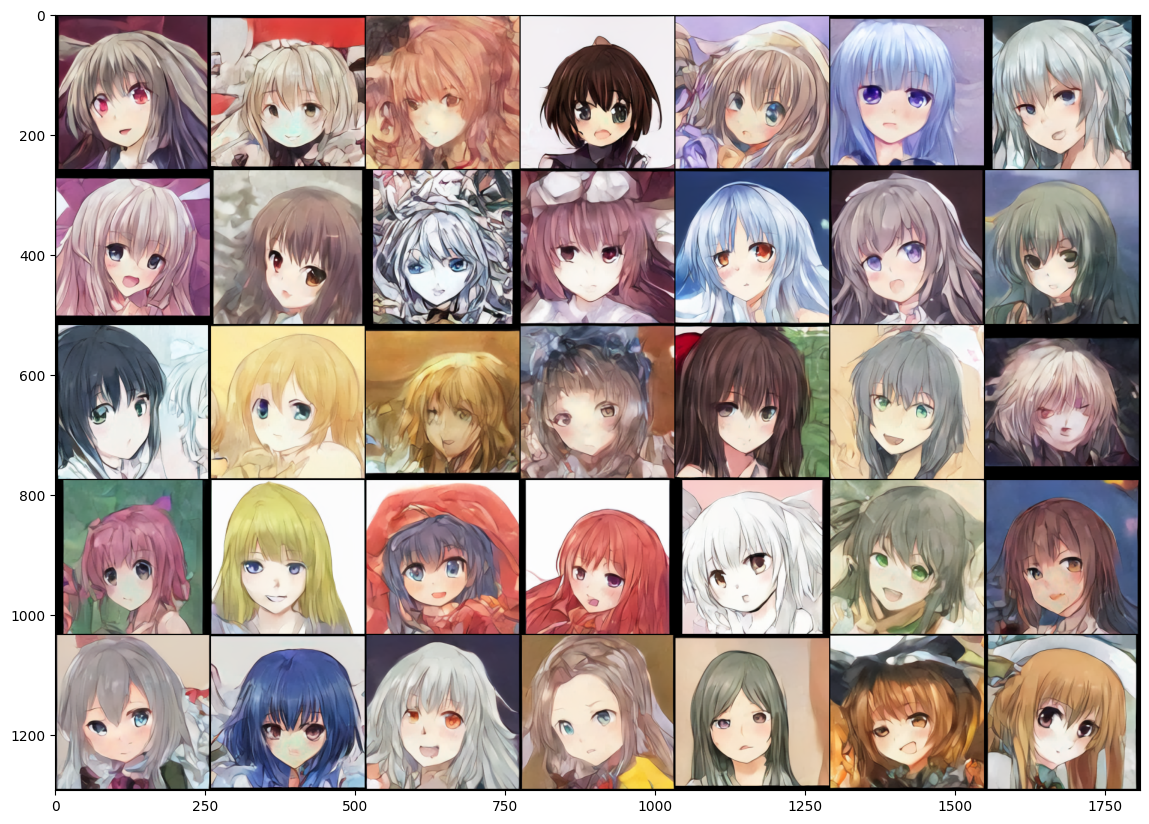

In [246]:
# @title
generated = make_sample(ema_unet, vae, 35)
grid = make_grid(generated, nrow=7)
plt.figure(figsize=(14,14))
plt.imshow(grid.permute(1, 2, 0).cpu().detach(), cmap="gray")
plt.show()